# Disease Prediction using Machine Learning


This notebook focuses on building machine learning models to predict diseases using patient health data.

The goal is to train multiple machine learning algorithms and identify the best-performing model for disease prediction.

---

## Dataset Used

patient_encoded.csv

The dataset contains:

• Patient demographics  
• Vital health indicators  
• Lifestyle factors  
• Symptoms  

Target Variable:

disease

---

## Models Trained

We will train and compare multiple models:

1. Logistic Regression
2. Random Forest
3. XGBoost
4. Support Vector Machine
5. K Nearest Neighbors
6. Gradient Boosting

---

## Workflow

1. Load dataset
2. Data preparation
3. Feature / target split
4. Train Test split
5. Feature scaling
6. Model training
7. Model evaluation
8. Model comparison
9. Best model selection
10. Model saving

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

### Load Dataset

In [2]:
df = pd.read_csv("../data/encoded/patient_encoded.csv")

df.head()

,patient_id,age,gender,height_cm,weight_kg,bmi,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,blood_glucose,...,city_Mumbai,city_Nagpur,city_Patna,city_Pune,city_Surat,city_Vadodara,region_East,region_North,region_South,region_West
0,1,0.371354,1,180.6,110.5,1.348390,165,94,0.653793,0.537891,...,False,True,False,False,False,False,False,False,False,True
1,2,-0.299145,1,164.1,62.8,-0.247616,123,88,-0.285231,1.651522,...,False,False,False,True,False,False,True,False,False,False
2,2,-0.299145,1,164.1,62.8,-0.247616,123,88,-0.285231,1.651522,...,False,False,False,True,False,False,True,False,False,False
3,3,0.505453,1,151.7,39.0,-1.211107,114,88,0.705961,-0.204529,...,False,False,False,True,False,False,False,True,False,False
4,4,1.377102,1,151.1,72.7,1.040566,136,88,0.784213,-1.021192,...,False,True,False,False,False,False,False,True,False,False


### Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254298 entries, 0 to 254297
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   patient_id                   254298 non-null  int64  
 1   age                          254298 non-null  float64
 2   gender                       254298 non-null  int64  
 3   height_cm                    254298 non-null  float64
 4   weight_kg                    254298 non-null  float64
 5   bmi                          254298 non-null  float64
 6   blood_pressure_systolic      254298 non-null  int64  
 7   blood_pressure_diastolic     254298 non-null  int64  
 8   cholesterol                  254298 non-null  float64
 9   blood_glucose                254298 non-null  float64
 10  heart_rate                   254298 non-null  int64  
 11  oxygen_level                 254298 non-null  int64  
 12  smoking_status               254298 non-null  int64  
 13 

In [4]:
df.describe()

,patient_id,age,gender,height_cm,weight_kg,bmi,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,blood_glucose,...,symptom_cough,symptom_fatigue,symptom_chest_pain,symptom_headache,symptom_shortness_of_breath,symptom_nausea,symptom_joint_pain,symptom_count,risk_score,lifestyle_risk
count,254298.000000,2.542980e+05,254298.000000,254298.000000,254298.000000,2.542980e+05,254298.000000,254298.000000,2.542980e+05,2.542980e+05,...,254298.000000,254298.000000,254298.000000,254298.000000,254298.000000,254298.000000,254298.000000,254298.000000,2.542980e+05,254298.0
mean,100060.570236,-1.604951e-16,0.510460,164.348713,66.591092,-1.065124e-16,129.949154,83.716942,-2.195072e-16,-2.333661e-16,...,0.121283,0.373625,0.176368,0.140693,0.228590,0.327022,0.037661,1.498753,-1.435067e-16,0.0
std,57753.282201,1.000002e+00,0.499892,10.104356,15.215228,1.000002e+00,17.650122,10.631735,1.000002e+00,1.000002e+00,...,0.326456,0.483767,0.381134,0.347705,0.419925,0.469126,0.190374,1.070774,1.000002e+00,0.0
min,1.000000,-1.908343e+00,0.000000,120.900000,1.600000,-3.689723e+00,90.000000,50.000000,-2.450203e+00,-1.874976e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.222866e+00,0.0
25%,50067.250000,-7.014447e-01,0.000000,157.500000,56.300000,-6.915693e-01,117.000000,77.000000,-6.764910e-01,-7.242236e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.016913e-01,0.0
50%,100124.000000,-3.094576e-02,1.000000,164.300000,66.600000,-5.466748e-02,130.000000,84.000000,1.692960e-03,-1.892399e-02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-1.563680e-02,0.0
75%,150045.750000,7.066031e-01,1.000000,171.200000,76.900000,6.338954e-01,143.000000,91.000000,6.798770e-01,6.863756e-01,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,6.781910e-01,0.0
max,200000.000000,2.919250e+00,1.000000,207.200000,135.200000,7.715901e+00,200.000000,120.000000,2.766597e+00,4.249995e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,4.270773e+00,0.0


### Define Features and Target

In [5]:
X = df.drop(columns=["patient_id","disease"])
y = df["disease"]

### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (203438, 51)
Testing samples: (50860, 51)


### Implement SMOTE

In [8]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train).value_counts())

Class distribution after SMOTE:
disease
5     68219
4     68219
0     68219
3     68219
6     68219
8     68219
10    68219
7     68219
9     68219
2     68219
1     68219
Name: count, dtype: int64


### Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training

In [11]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=200),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
}

### Train and Evaluate Models

In [12]:
results = []

for name, model in models.items():

    print("Training:", name)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print("Accuracy:", accuracy)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n-------------------------------------\n")

Training: Logistic Regression
Accuracy: 0.9512386944553677

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1866
           1       0.24      0.48      0.32       506
           2       0.98      0.99      0.98       389
           3       0.96      0.88      0.92     13469
           4       1.00      0.99      1.00     17055
           5       0.99      1.00      0.99      7649
           6       0.98      0.99      0.98      4977
           7       0.60      0.81      0.69      1587
           8       0.94      1.00      0.97       923
           9       0.86      0.98      0.91       425
          10       0.99      1.00      1.00      2014

    accuracy                           0.95     50860
   macro avg       0.87      0.92      0.88     50860
weighted avg       0.96      0.95      0.96     50860


Confusion Matrix:
[[ 1789     0     0     0     1    24     0     0    51     0     1]
 [    0   241   

### Compare Model Performance

In [13]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,SVM,0.952969
5,XGBoost,0.952871
2,Gradient Boosting,0.951278
0,Logistic Regression,0.951239
1,Random Forest,0.949587
4,KNN,0.900983


### Visualization

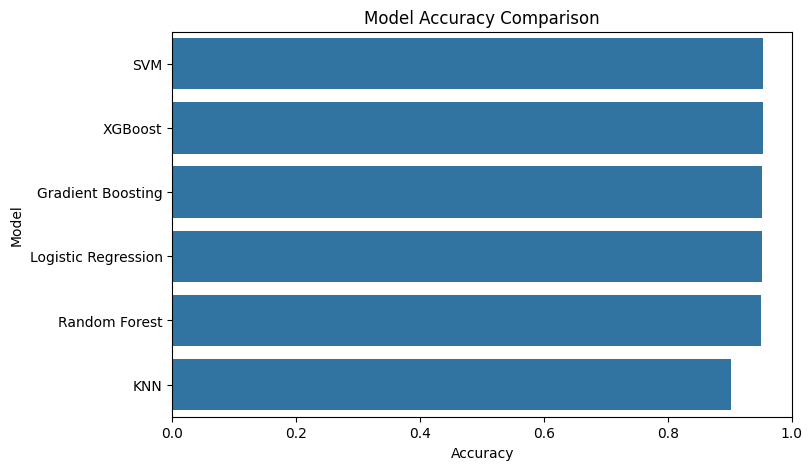

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results_df.sort_values("Accuracy",ascending=False)
)

plt.title("Model Accuracy Comparison")
plt.show()

### Save Best Model

In [10]:
best_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

best_model.fit(X_train_scaled, y_train)


,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [11]:
joblib.dump(best_model,"../models/disease_prediction_model.pkl")

['../models/disease_prediction_model.pkl']

In [12]:
joblib.dump(scaler,"../models/scaler.pkl")

['../models/scaler.pkl']

## Conclusion

Multiple machine learning models were trained to predict diseases using patient health data.

Models compared:

• Logistic Regression  
• Random Forest  
• Gradient Boosting  
• SVM  
• KNN  
• XGBoost  

The best performing model was selected based on accuracy and classification performance.

The final trained model and scaler were saved for deployment.
